## Examine how the temperatures at upper and lower stations are changing over time

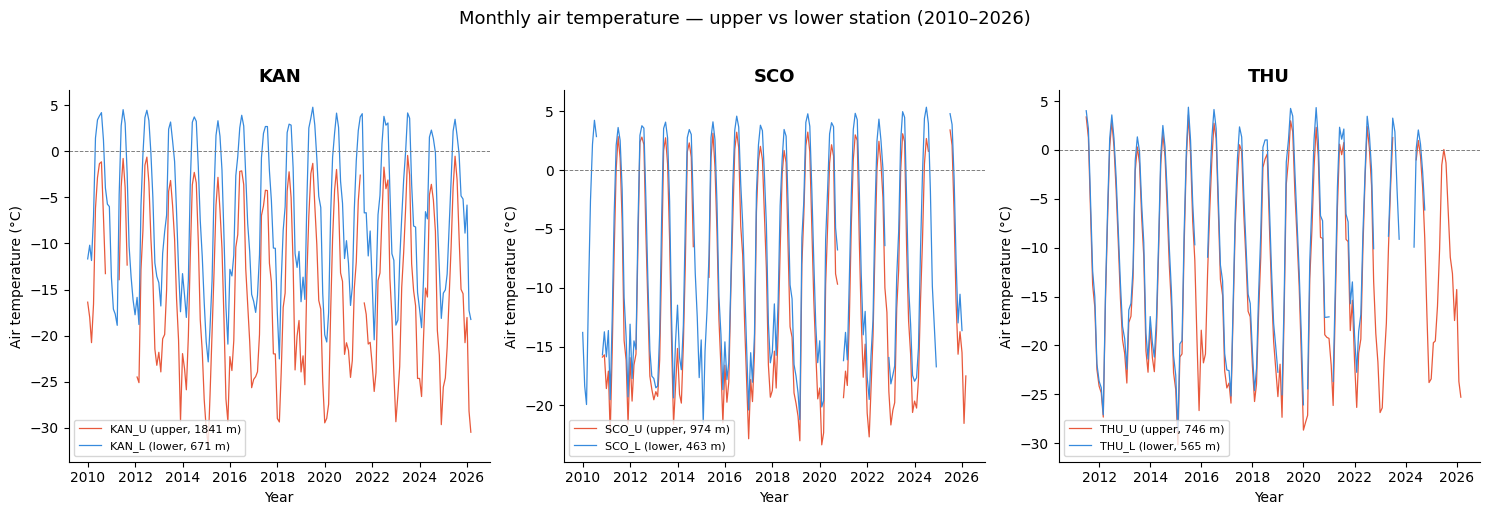

✅ Saved: temperature_timeseries_KAN_SCO_THU.png


In [1]:
## Temperature time series: KAN, SCO, THU — upper vs lower station
# raw monthly temperature only, different colors for upper and lower

# ── Imports and paths ──────────────────────────────────────────────────────────
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

PROJECT_ROOT = Path.cwd()
CLEAN_DATA   = PROJECT_ROOT / "Data" / "Data_Processed" / "Cleaned_Stations"
FIGURE_DIR   = PROJECT_ROOT / "Figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

# ── Stations to plot ───────────────────────────────────────────────────────────
SITES = ["KAN", "SCO", "THU"]

# upper = warm coral, lower = cool blue
COLOR_UPPER = "#E8593C"
COLOR_LOWER = "#378ADD"

# ── Load data helper ───────────────────────────────────────────────────────────
def load_station(site, position):
    """Load cleaned monthly CSV for one station."""
    path = CLEAN_DATA / f"{site}_{position}_month_clean.csv"
    df   = pd.read_csv(path, parse_dates=["time"])
    return df.sort_values("time").set_index("time")

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=False)

for ax, site in zip(axes, SITES):

    upper = load_station(site, "U")
    lower = load_station(site, "L")

    # raw monthly temperature lines
    ax.plot(upper.index, upper["t_u"],
            color=COLOR_UPPER, linewidth=0.9,
            label=f"{site}_U (upper, {upper['gps_alt'].median():.0f} m)")
    ax.plot(lower.index, lower["t_u"],
            color=COLOR_LOWER, linewidth=0.9,
            label=f"{site}_L (lower, {lower['gps_alt'].median():.0f} m)")

    # 0°C reference line
    ax.axhline(0, color="grey", linewidth=0.7, linestyle="--")

    ax.set_title(site, fontsize=13, fontweight="bold")
    ax.set_xlabel("Year")
    ax.set_ylabel("Air temperature (°C)")
    ax.legend(fontsize=8, loc="lower left")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig.suptitle("Monthly air temperature — upper vs lower station (2010–2026)",
             fontsize=13, y=1.02)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "temperature_timeseries_KAN_SCO_THU.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: temperature_timeseries_KAN_SCO_THU.png")

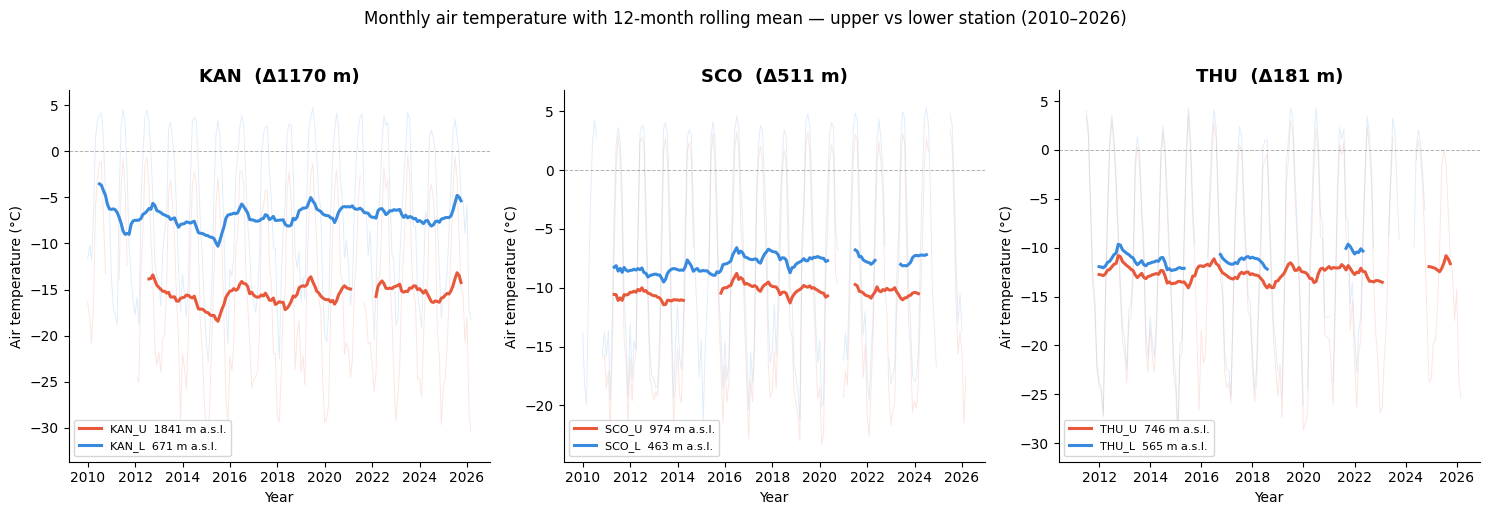

✅ Saved: temperature_timeseries_KAN_SCO_THU.png


In [2]:
## Temperature time series: KAN, SCO, THU — raw monthly + 12-month rolling mean
# faint lines = raw monthly data (seasonal cycle visible)
# bold lines   = 12-month rolling mean (long-term signal)

# ── Imports and paths ──────────────────────────────────────────────────────────
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

PROJECT_ROOT = Path.cwd()
CLEAN_DATA   = PROJECT_ROOT / "Data" / "Data_Processed" / "Cleaned_Stations"
FIGURE_DIR   = PROJECT_ROOT / "Figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

SITES       = ["KAN", "SCO", "THU"]
COLOR_UPPER = "#E8593C"   # warm coral = upper station
COLOR_LOWER = "#378ADD"   # cool blue  = lower station

# ── Load helper ────────────────────────────────────────────────────────────────
def load_station(site, position):
    path = CLEAN_DATA / f"{site}_{position}_month_clean.csv"
    df   = pd.read_csv(path, parse_dates=["time"])
    return df.sort_values("time").set_index("time")

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=False)

for ax, site in zip(axes, SITES):
    upper = load_station(site, "U")
    lower = load_station(site, "L")

    elev_u = upper["gps_alt"].median()
    elev_l = lower["gps_alt"].median()

    # faint raw monthly data — shows seasonal cycle
    ax.plot(upper.index, upper["t_u"],
            color=COLOR_UPPER, alpha=0.15, linewidth=0.7)
    ax.plot(lower.index, lower["t_u"],
            color=COLOR_LOWER, alpha=0.15, linewidth=0.7)

    # bold 12-month rolling mean — shows long-term signal
    ax.plot(upper.index, upper["t_u"].rolling(12, center=True).mean(),
            color=COLOR_UPPER, linewidth=2.2,
            label=f"{site}_U  {elev_u:.0f} m a.s.l.")
    ax.plot(lower.index, lower["t_u"].rolling(12, center=True).mean(),
            color=COLOR_LOWER, linewidth=2.2,
            label=f"{site}_L  {elev_l:.0f} m a.s.l.")

    # 0°C reference line
    ax.axhline(0, color="grey", linewidth=0.7, linestyle="--", alpha=0.6)

    ax.set_title(f"{site}  (Δ{elev_u - elev_l:.0f} m)",
                 fontsize=13, fontweight="bold")
    ax.set_xlabel("Year")
    ax.set_ylabel("Air temperature (°C)")
    ax.legend(fontsize=8, loc="lower left")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig.suptitle("Monthly air temperature with 12-month rolling mean — upper vs lower station (2010–2026)",
             fontsize=12, y=1.02)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "temperature_timeseries_KAN_SCO_THU.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: temperature_timeseries_KAN_SCO_THU.png")

### Data check for THU due to strong data gaps

In [3]:
# ── Diagnose THU data gaps ─────────────────────────────────────────────────────
thu_l = pd.read_csv(CLEAN_DATA / "THU_L_month_clean.csv", parse_dates=["time"])
thu_u = pd.read_csv(CLEAN_DATA / "THU_U_month_clean.csv", parse_dates=["time"])

print("THU_L rows:", len(thu_l), "| range:", thu_l["time"].min(), "→", thu_l["time"].max())
print("THU_U rows:", len(thu_u), "| range:", thu_u["time"].min(), "→", thu_u["time"].max())

print("\nTHU_L t_u NaN:", thu_l["t_u"].isna().sum(), "/", len(thu_l))
print("THU_U t_u NaN:", thu_u["t_u"].isna().sum(), "/", len(thu_u))

# check where the gaps are — which years are missing
print("\nTHU_L missing years/months:")
full_range = pd.date_range(thu_l["time"].min(), thu_l["time"].max(), freq="MS")
missing = full_range[~full_range.isin(thu_l["time"])]
print(missing)

print("\nTHU_U missing years/months:")
full_range = pd.date_range(thu_u["time"].min(), thu_u["time"].max(), freq="MS")
missing = full_range[~full_range.isin(thu_u["time"])]
print(missing)

THU_L rows: 181 | range: 2010-08-01 00:00:00 → 2025-08-01 00:00:00
THU_U rows: 181 | range: 2010-08-01 00:00:00 → 2026-04-01 00:00:00

THU_L t_u NaN: 40 / 181
THU_U t_u NaN: 14 / 181

THU_L missing years/months:
DatetimeIndex([], dtype='datetime64[us]', freq='MS')

THU_U missing years/months:
DatetimeIndex(['2023-09-01', '2023-10-01', '2023-11-01', '2023-12-01',
               '2024-01-01', '2024-02-01', '2024-03-01', '2024-04-01'],
              dtype='datetime64[us]', freq='MS')


In [4]:
# ── Where are THU_L NaNs concentrated? ────────────────────────────────────────
thu_l["year"] = thu_l["time"].dt.year

print("THU_L NaN count per year:")
print(thu_l.groupby("year")["t_u"].apply(lambda x: x.isna().sum())
      .rename("NaN count").to_string())

THU_L NaN count per year:
year
2010    5
2011    5
2012    0
2013    0
2014    0
2015    2
2016    3
2017    0
2018    0
2019    1
2020    1
2021    1
2022    2
2023    6
2024    6
2025    8


In [5]:
# ── Sensitivity check: rerun THU MK on clean middle period only ───────────────
import pymannkendall as mk
import pandas as pd
from pathlib import Path

PROJECT_ROOT   = Path.cwd()
PROCESSED_DATA = PROJECT_ROOT / "Data" / "Data_Processed"

pairs = pd.read_csv(PROCESSED_DATA / "station_pairs_monthly.csv", 
                    parse_dates=["time"])

# full record (as used in main analysis)
thu_full = (pairs[pairs["site"] == "THU"]
            .sort_values("time")["gradient_per100m"]
            .dropna())

# clean middle period only 2012-2022
thu_clean = (pairs[(pairs["site"] == "THU") & 
                   (pairs["time"].dt.year.between(2012, 2022))]
             .sort_values("time")["gradient_per100m"]
             .dropna())

res_full  = mk.original_test(thu_full)
res_clean = mk.original_test(thu_clean)

print("THU full record:")
print(f"  n={len(thu_full)}  τ={res_full.Tau:.3f}  p={res_full.p:.4f}  Sen={res_full.slope*12:.5f} °C/100m/yr")

print("\nTHU clean period (2012-2022):")
print(f"  n={len(thu_clean)}  τ={res_clean.Tau:.3f}  p={res_clean.p:.4f}  Sen={res_clean.slope*12:.5f} °C/100m/yr")

THU full record:
  n=136  τ=-0.418  p=0.0000  Sen=-0.05863 °C/100m/yr

THU clean period (2012-2022):
  n=122  τ=-0.470  p=0.0000  Sen=-0.06885 °C/100m/yr


---------
---------

# Temperature Analysis - comparing upper and lower stations for seasonality

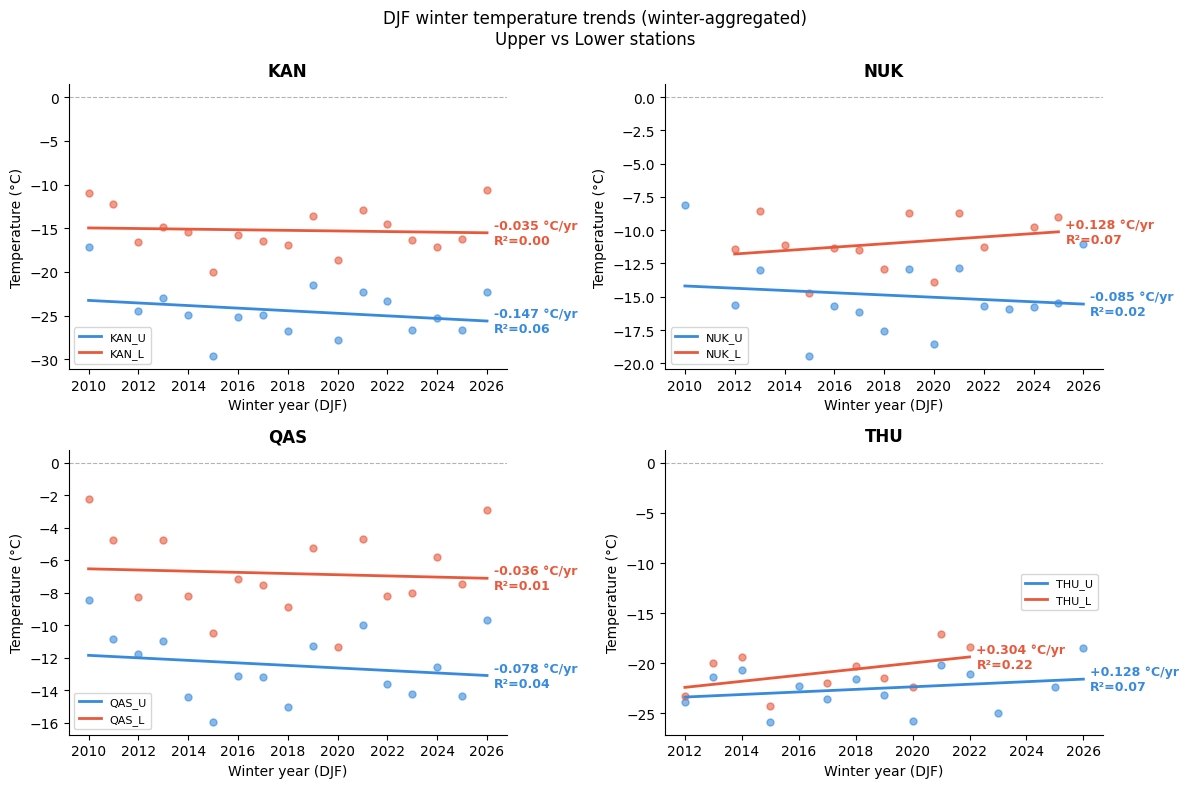

✅ Saved: c:\Users\miria\Documents\UNI\4_Semester\SEMINAR_PHY\SE_402.212_GreenlandTemperature\Figures\DJF_winter_trends_corrected.png


In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ── Paths ──────────────────────────────────────────────────────────────────────
PROJECT_ROOT = Path.cwd()
CLEAN_DATA = PROJECT_ROOT / "Data" / "Data_Processed" / "Cleaned_Stations"
FIGURE_DIR = PROJECT_ROOT / "Figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

SITES = ["KAN", "NUK", "QAS", "THU"]

COLOR_UPPER = "#378ADD"
COLOR_LOWER = "#E8593C"


# ── Load + correct DJF aggregation ────────────────────────────────────────────
def load_djf_winter_mean(site, position):
    path = CLEAN_DATA / f"{site}_{position}_month_clean.csv"
    df = pd.read_csv(path, parse_dates=["time"])
    df = df.sort_values("time")

    # Keep DJF
    df = df[df["time"].dt.month.isin([12, 1, 2])]
    df = df.dropna(subset=["t_u"])

    # Define winter year:
    # Dec belongs to next year's winter
    df["winter_year"] = np.where(
        df["time"].dt.month == 12,
        df["time"].dt.year + 1,
        df["time"].dt.year
    )

    # Aggregate to ONE value per winter
    df_winter = df.groupby("winter_year")["t_u"].mean().reset_index()

    return df_winter


# ── Figure setup ───────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, site in zip(axes, SITES):

    upper = load_djf_winter_mean(site, "U")
    lower = load_djf_winter_mean(site, "L")

    if len(upper) < 3 or len(lower) < 3:
        ax.set_title(f"{site} (insufficient data)")
        ax.axis("off")
        continue

    # ── Regression function ───────────────────────────────────────────────────
    def add_trend(ax, df, color, label):

        x = df["winter_year"].to_numpy()
        y = df["t_u"].to_numpy()

        m, b = np.polyfit(x, y, 1)
        y_pred = m * x + b

        # Proper R² (NOT correlation shortcut)
        r2 = 1 - np.sum((y - y_pred)**2) / np.sum((y - np.mean(y))**2)

        ax.plot(x, y_pred, color=color, linewidth=2, label=label)

        ax.annotate(
            f"{m:+.3f} °C/yr\nR²={r2:.2f}",
            xy=(x[-1], y_pred[-1]),
            xytext=(5, 0),
            textcoords="offset points",
            color=color,
            fontsize=9,
            fontweight="bold",
            ha="left",
            va="center"
        )

    # ── Scatter ───────────────────────────────────────────────────────────────
    ax.scatter(upper["winter_year"], upper["t_u"],
               color=COLOR_UPPER, alpha=0.6, s=25)

    ax.scatter(lower["winter_year"], lower["t_u"],
               color=COLOR_LOWER, alpha=0.6, s=25)

    # ── Trends ────────────────────────────────────────────────────────────────
    add_trend(ax, upper, COLOR_UPPER, f"{site}_U")
    add_trend(ax, lower, COLOR_LOWER, f"{site}_L")

    # Reference line
    ax.axhline(0, color="grey", linestyle="--", linewidth=0.8, alpha=0.6)

    # Formatting
    ax.set_title(site, fontweight="bold")
    ax.set_xlabel("Winter year (DJF)")
    ax.set_ylabel("Temperature (°C)")
    ax.legend(fontsize=8)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


fig.suptitle(
    "DJF winter temperature trends (winter-aggregated)\nUpper vs Lower stations",
    fontsize=12
)

fig.tight_layout()

output_path = FIGURE_DIR / "DJF_winter_trends_corrected.png"
fig.savefig(output_path, dpi=150, bbox_inches="tight")

plt.show()

print(f"✅ Saved: {output_path}")

Temperature Change for upper and lower stations for Summer (JJA)

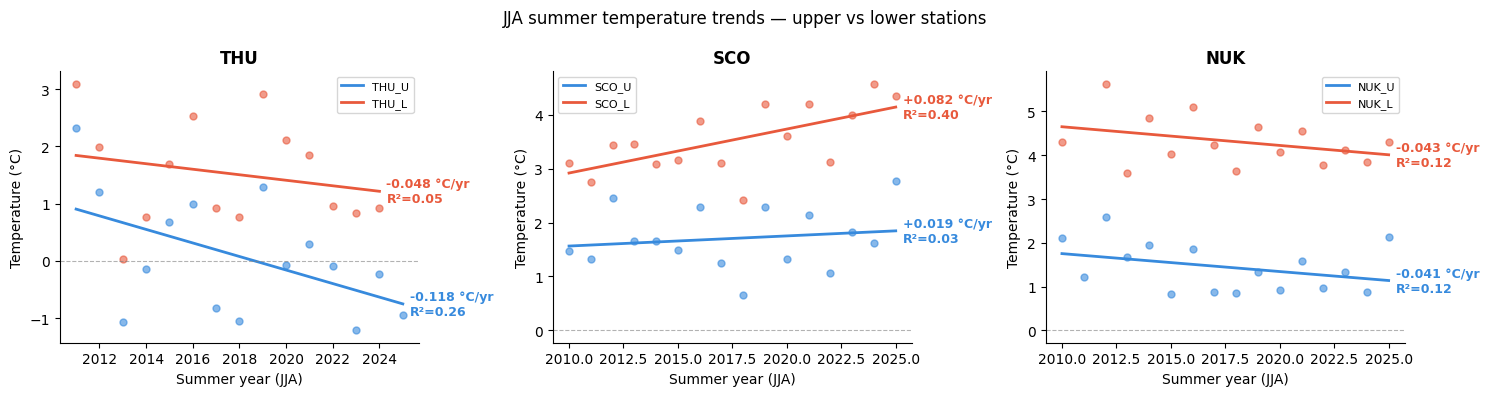

✅ Saved: c:\Users\miria\Documents\UNI\4_Semester\SEMINAR_PHY\SE_402.212_GreenlandTemperature\Figures\JJA_temperature_trends_THU_SCO_NUK.png


In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ── Paths ──────────────────────────────────────────────────────────────────────
PROJECT_ROOT = Path.cwd()
CLEAN_DATA = PROJECT_ROOT / "Data" / "Data_Processed" / "Cleaned_Stations"
FIGURE_DIR = PROJECT_ROOT / "Figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

# ── Settings ───────────────────────────────────────────────────────────────────
SITES = ["THU", "SCO", "NUK"]

COLOR_UPPER = "#378ADD"
COLOR_LOWER = "#E8593C"

# ── Load + JJA aggregation ────────────────────────────────────────────────────
def load_jja_summer_mean(site, position):
    path = CLEAN_DATA / f"{site}_{position}_month_clean.csv"
    df = pd.read_csv(path, parse_dates=["time"])
    df = df.sort_values("time")

    # Keep JJA only
    df = df[df["time"].dt.month.isin([6, 7, 8])]
    df = df.dropna(subset=["t_u"])

    # Summer year = same calendar year (no shift needed)
    df["summer_year"] = df["time"].dt.year

    # Aggregate → one value per summer
    df_summer = df.groupby("summer_year")["t_u"].mean().reset_index()

    return df_summer


# ── Plot setup ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes = axes.flatten()


def add_trend(ax, df, color, label):

    x = df["summer_year"].to_numpy()
    y = df["t_u"].to_numpy()

    m, b = np.polyfit(x, y, 1)
    y_pred = m * x + b

    r2 = 1 - np.sum((y - y_pred)**2) / np.sum((y - np.mean(y))**2)

    ax.plot(x, y_pred, color=color, linewidth=2, label=label)

    ax.annotate(
        f"{m:+.3f} °C/yr\nR²={r2:.2f}",
        xy=(x[-1], y_pred[-1]),
        xytext=(5, 0),
        textcoords="offset points",
        color=color,
        fontsize=9,
        fontweight="bold",
        ha="left",
        va="center"
    )


for ax, site in zip(axes, SITES):

    upper = load_jja_summer_mean(site, "U")
    lower = load_jja_summer_mean(site, "L")

    if len(upper) < 3 or len(lower) < 3:
        ax.set_title(f"{site} (insufficient data)")
        ax.axis("off")
        continue

    # Scatter
    ax.scatter(upper["summer_year"], upper["t_u"],
               color=COLOR_UPPER, alpha=0.6, s=25)

    ax.scatter(lower["summer_year"], lower["t_u"],
               color=COLOR_LOWER, alpha=0.6, s=25)

    # Trends
    add_trend(ax, upper, COLOR_UPPER, f"{site}_U")
    add_trend(ax, lower, COLOR_LOWER, f"{site}_L")

    # Formatting
    ax.set_title(site, fontweight="bold")
    ax.set_xlabel("Summer year (JJA)")
    ax.set_ylabel("Temperature (°C)")
    ax.axhline(0, color="grey", linestyle="--", linewidth=0.8, alpha=0.6)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.legend(fontsize=8)

fig.suptitle(
    "JJA summer temperature trends — upper vs lower stations",
    fontsize=12
)

fig.tight_layout()

output_path = FIGURE_DIR / "JJA_temperature_trends_THU_SCO_NUK.png"
fig.savefig(output_path, dpi=150, bbox_inches="tight")

plt.show()

print(f"✅ Saved: {output_path}")

In [2]:
import pandas as pd
import numpy as np
import pymannkendall as mk
from pathlib import Path

# ── Settings ────────────────────────────────────────────────────────────────
PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / "Data" / "Data_Processed" / "Cleaned_Stations"
RESULTS_DIR = PROJECT_ROOT / "Results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

SITES = ["KAN", "NUK", "QAS", "THU", "SCO"]

# ── Season extraction ────────────────────────────────────────────────────────
def get_season_series(df, season):

    if season == "DJF":
        df = df[df["time"].dt.month.isin([12, 1, 2])]

        # winter year
        df["year"] = np.where(
            df["time"].dt.month == 12,
            df["time"].dt.year + 1,
            df["time"].dt.year
        )

    elif season == "JJA":
        df = df[df["time"].dt.month.isin([6, 7, 8])]
        df["year"] = df["time"].dt.year

    else:
        raise ValueError("Use DJF or JJA")

    # seasonal mean per year
    return df.groupby("year")["t_u"].mean().dropna()


# ── MK analysis function ─────────────────────────────────────────────────────
def run_mk(series):

    result = mk.original_test(series)

    return {
        "trend": result.trend,
        "p": result.p,
        "tau": result.Tau,
        "slope": result.slope
    }


# ── Main loop ────────────────────────────────────────────────────────────────
results = []

for site in SITES:

    path_u = DATA_DIR / f"{site}_U_month_clean.csv"
    path_l = DATA_DIR / f"{site}_L_month_clean.csv"

    for position, path in [("U", path_u), ("L", path_l)]:

        df = pd.read_csv(path, parse_dates=["time"])

        for season in ["DJF", "JJA"]:

            series = get_season_series(df.copy(), season)

            if len(series) < 5:
                continue

            mk_res = run_mk(series)

            results.append({
                "site": site,
                "station": position,
                "season": season,
                "n_years": len(series),
                "trend": mk_res["trend"],
                "p_value": mk_res["p"],
                "tau": mk_res["tau"],
                "sen_slope": mk_res["slope"]
            })


# ── Results table ────────────────────────────────────────────────────────────
results_df = pd.DataFrame(results)

print("\n📊 Mann-Kendall + Sen slope results:\n")
print(results_df.sort_values(["site", "season", "station"]))

# Optional save
results_df.to_csv(RESULTS_DIR / "MK_Sen_results_DJF_JJA.csv", index=False)
print("✅ Saved: Results/MK_Sen_results_DJF_JJA.csv")


📊 Mann-Kendall + Sen slope results:

   site station season  n_years       trend   p_value       tau  sen_slope
2   KAN       L    DJF       17    no trend  0.650463 -0.088235  -0.075967
0   KAN       U    DJF       16    no trend  0.444044 -0.150000  -0.109548
3   KAN       L    JJA       16    no trend  0.052872 -0.366667  -0.077174
1   KAN       U    JJA       16    no trend  0.260351 -0.216667  -0.092842
6   NUK       L    DJF       13    no trend  0.669334  0.102564   0.096522
4   NUK       U    DJF       15    no trend  0.921159  0.028571   0.012567
7   NUK       L    JJA       15    no trend  0.373053 -0.180952  -0.042790
5   NUK       U    JJA       16    no trend  0.344418 -0.183333  -0.039482
10  QAS       L    DJF       17    no trend  0.967142 -0.014706  -0.012840
8   QAS       U    DJF       16    no trend  0.444044 -0.150000  -0.124413
11  QAS       L    JJA       16    no trend  0.162805  0.266667   0.041034
9   QAS       U    JJA       14    no trend  0.742557  0.07692

## Winter Temperature at all Stations 

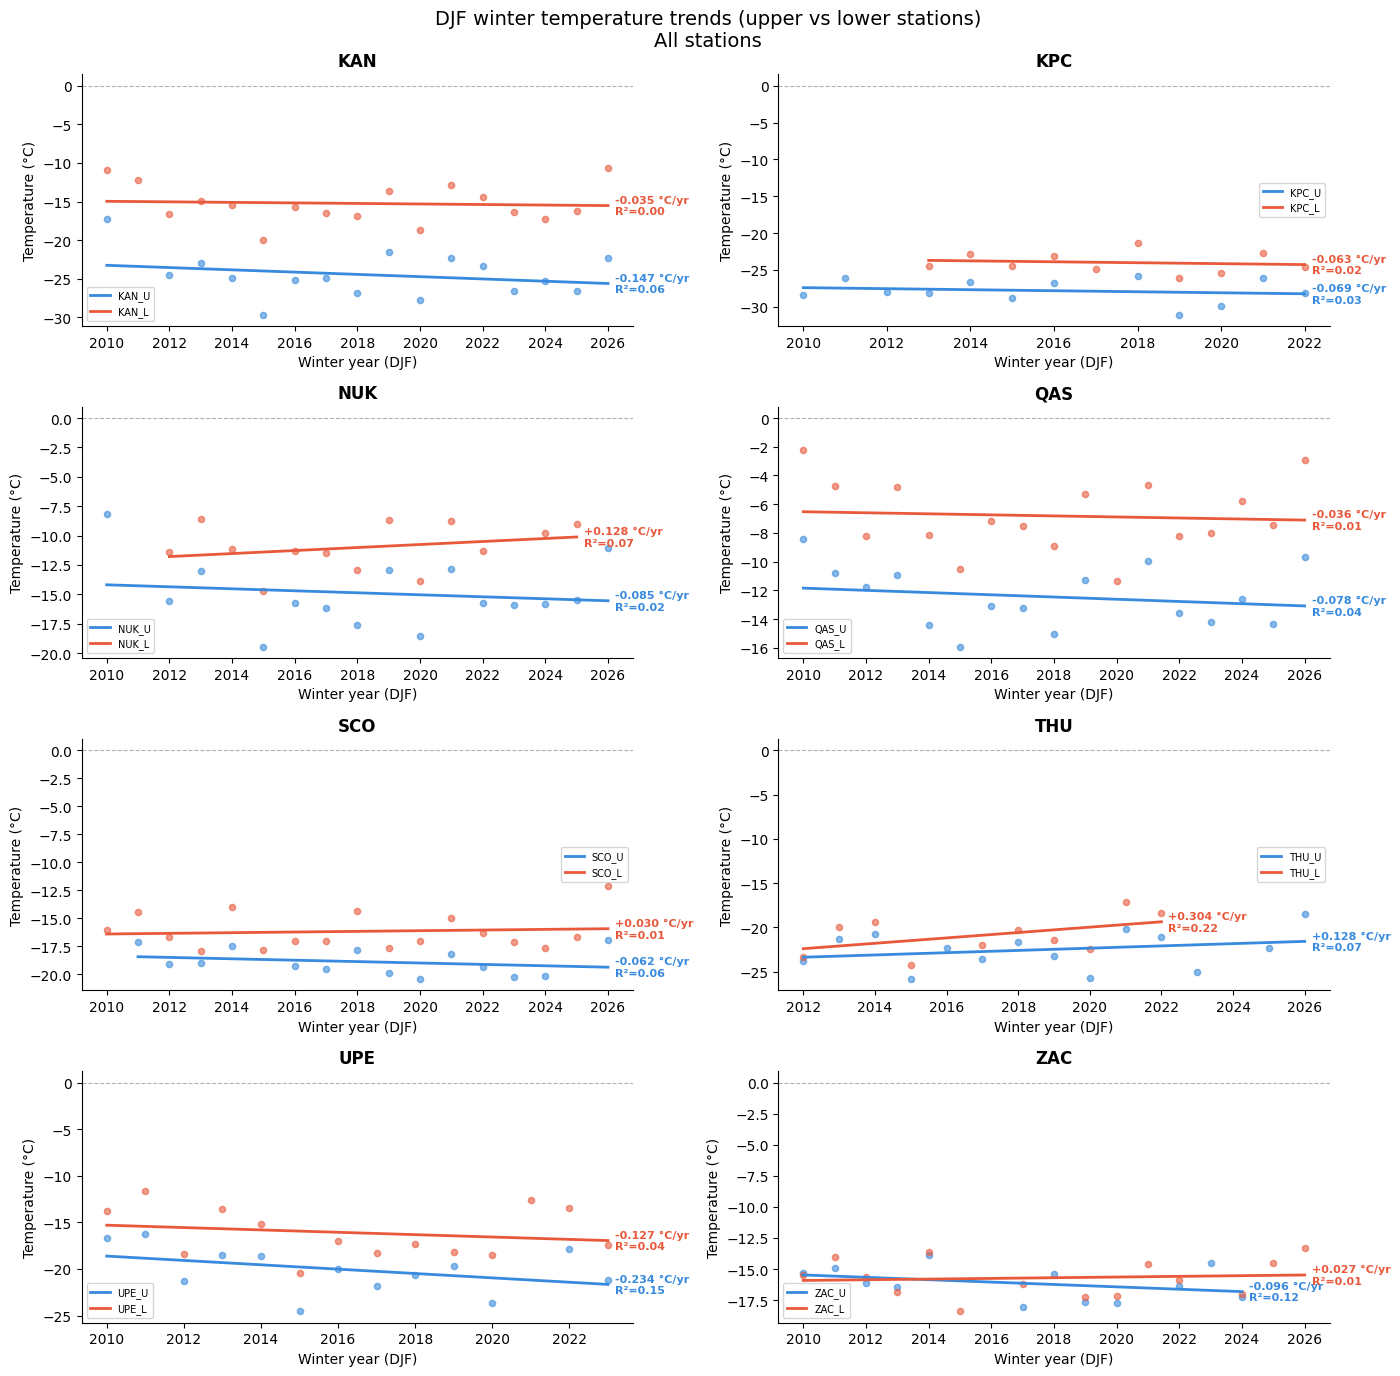

✅ Saved: c:\Users\miria\Documents\UNI\4_Semester\SEMINAR_PHY\SE_402.212_GreenlandTemperature\Figures\DJF_all_stations_trends.png


In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ── Paths ──────────────────────────────────────────────────────────────────────
PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / "Data" / "Data_Processed" / "Cleaned_Stations"
FIGURE_DIR = PROJECT_ROOT / "Figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

# ── Stations ──────────────────────────────────────────────────────────────────
SITES = ["KAN", "KPC", "NUK", "QAS", "SCO", "THU", "UPE", "ZAC"]

COLOR_UPPER = "#378ADD"
COLOR_LOWER = "#E8593C"


# ── DJF aggregation ───────────────────────────────────────────────────────────
def load_djf(site, position):

    path = DATA_DIR / f"{site}_{position}_month_clean.csv"
    df = pd.read_csv(path, parse_dates=["time"])
    df = df.sort_values("time")

    # DJF only
    df = df[df["time"].dt.month.isin([12, 1, 2])]
    df = df.dropna(subset=["t_u"])

    # winter year
    df["winter_year"] = np.where(
        df["time"].dt.month == 12,
        df["time"].dt.year + 1,
        df["time"].dt.year
    )

    # mean per winter
    return df.groupby("winter_year")["t_u"].mean().reset_index()


# ── Trend helper ──────────────────────────────────────────────────────────────
def add_trend(ax, df, color, label):

    x = df["winter_year"].to_numpy()
    y = df["t_u"].to_numpy()

    m, b = np.polyfit(x, y, 1)
    y_pred = m * x + b

    r2 = 1 - np.sum((y - y_pred)**2) / np.sum((y - np.mean(y))**2)

    ax.plot(x, y_pred, color=color, linewidth=2, label=label)

    ax.annotate(
        f"{m:+.3f} °C/yr\nR²={r2:.2f}",
        xy=(x[-1], y_pred[-1]),
        xytext=(5, 0),
        textcoords="offset points",
        color=color,
        fontsize=8,
        fontweight="bold",
        ha="left",
        va="center"
    )


# ── Plot setup ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(4, 2, figsize=(14, 14))
axes = axes.flatten()


for ax, site in zip(axes, SITES):

    try:
        upper = load_djf(site, "U")
        lower = load_djf(site, "L")
    except Exception:
        ax.set_title(f"{site} (missing data)")
        ax.axis("off")
        continue

    if len(upper) < 3 or len(lower) < 3:
        ax.set_title(f"{site} (insufficient data)")
        ax.axis("off")
        continue

    # Scatter
    ax.scatter(upper["winter_year"], upper["t_u"],
               color=COLOR_UPPER, alpha=0.6, s=20)

    ax.scatter(lower["winter_year"], lower["t_u"],
               color=COLOR_LOWER, alpha=0.6, s=20)

    # Trends
    add_trend(ax, upper, COLOR_UPPER, f"{site}_U")
    add_trend(ax, lower, COLOR_LOWER, f"{site}_L")

    # Formatting
    ax.set_title(site, fontweight="bold")
    ax.set_xlabel("Winter year (DJF)")
    ax.set_ylabel("Temperature (°C)")
    ax.axhline(0, color="grey", linestyle="--", linewidth=0.8, alpha=0.6)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.legend(fontsize=7, loc="best")


# Hide empty axes if any
for ax in axes[len(SITES):]:
    ax.axis("off")


fig.suptitle(
    "DJF winter temperature trends (upper vs lower stations)\nAll stations",
    fontsize=14
)

fig.tight_layout()

output_path = FIGURE_DIR / "DJF_all_stations_trends.png"
fig.savefig(output_path, dpi=150, bbox_inches="tight")

plt.show()

print(f"✅ Saved: {output_path}")

## Summer Temperatures all stations JJA 

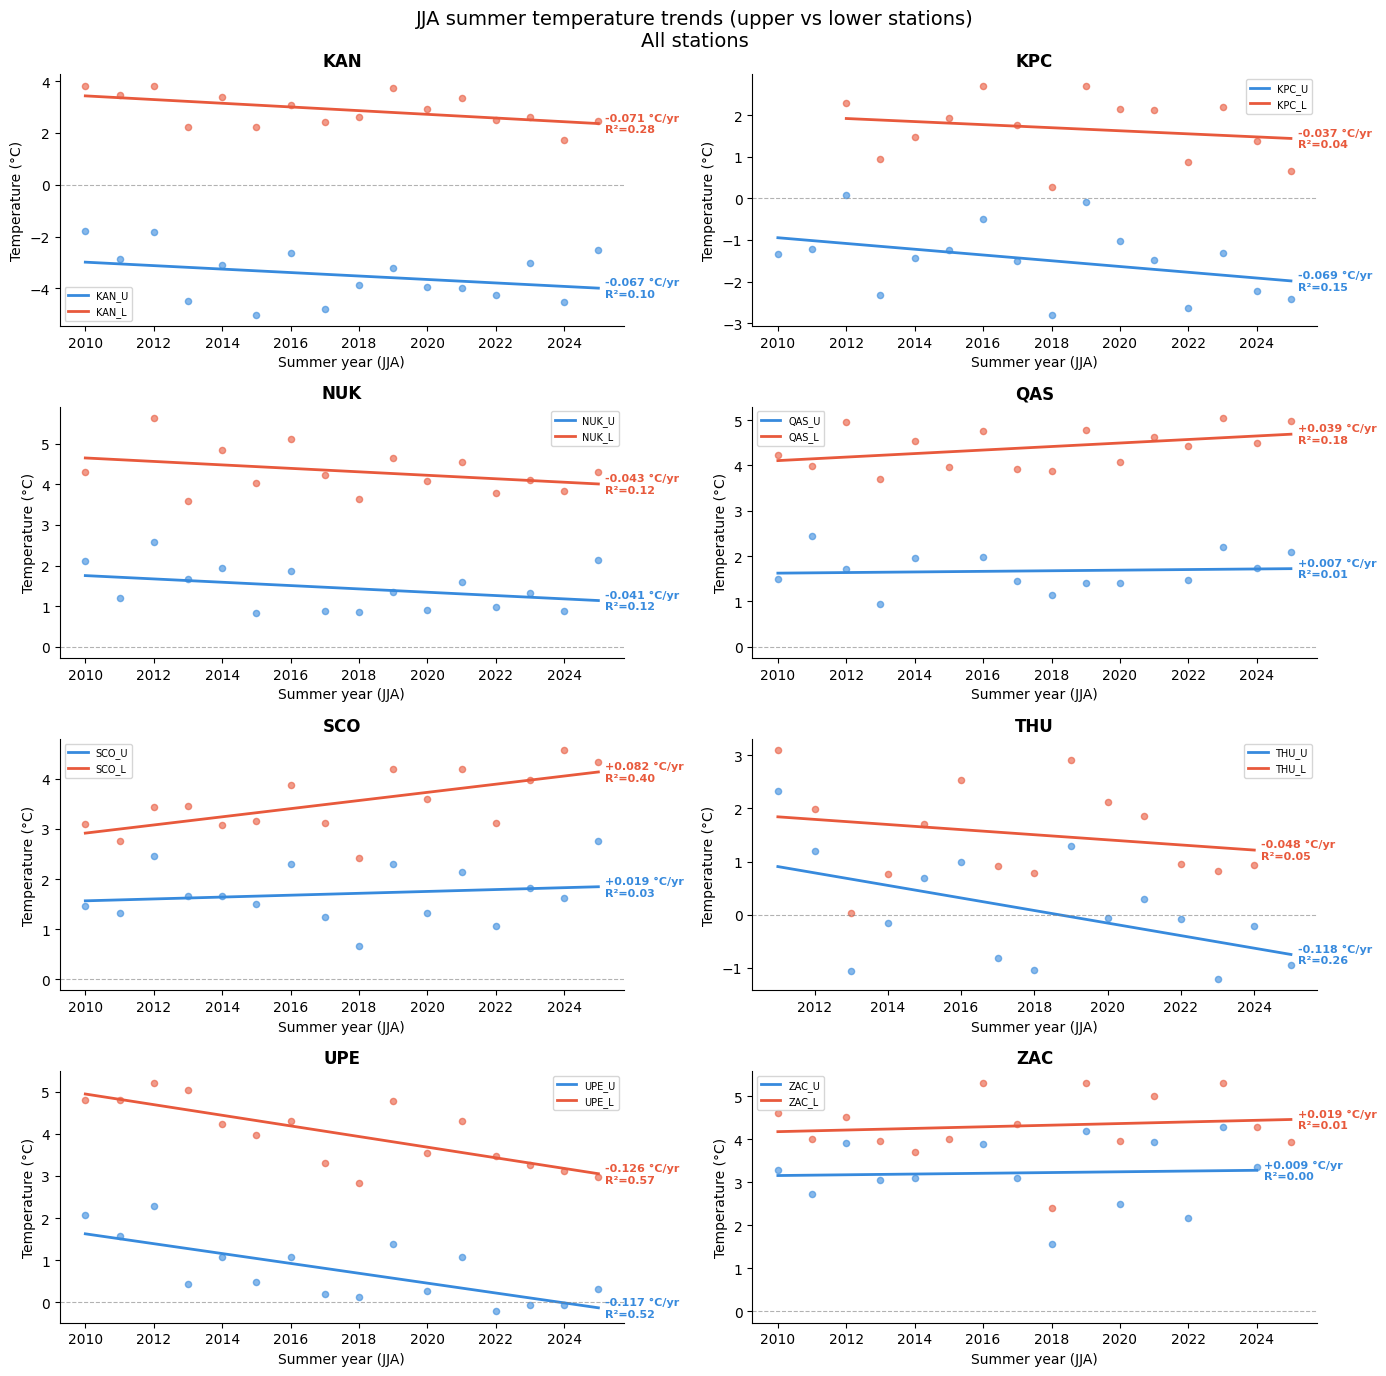

✅ Saved: c:\Users\miria\Documents\UNI\4_Semester\SEMINAR_PHY\SE_402.212_GreenlandTemperature\Figures\JJA_all_stations_trends.png


In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ── Paths ──────────────────────────────────────────────────────────────────────
PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / "Data" / "Data_Processed" / "Cleaned_Stations"
FIGURE_DIR = PROJECT_ROOT / "Figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

# ── Stations ──────────────────────────────────────────────────────────────────
SITES = ["KAN", "KPC", "NUK", "QAS", "SCO", "THU", "UPE", "ZAC"]

COLOR_UPPER = "#378ADD"
COLOR_LOWER = "#E8593C"


# ── JJA aggregation ───────────────────────────────────────────────────────────
def load_jja(site, position):

    path = DATA_DIR / f"{site}_{position}_month_clean.csv"
    df = pd.read_csv(path, parse_dates=["time"])
    df = df.sort_values("time")

    # JJA only
    df = df[df["time"].dt.month.isin([6, 7, 8])]
    df = df.dropna(subset=["t_u"])

    # summer year (same calendar year)
    df["summer_year"] = df["time"].dt.year

    return df.groupby("summer_year")["t_u"].mean().reset_index()


# ── Trend function ────────────────────────────────────────────────────────────
def add_trend(ax, df, color, label):

    x = df["summer_year"].to_numpy()
    y = df["t_u"].to_numpy()

    m, b = np.polyfit(x, y, 1)
    y_pred = m * x + b

    r2 = 1 - np.sum((y - y_pred)**2) / np.sum((y - np.mean(y))**2)

    ax.plot(x, y_pred, color=color, linewidth=2, label=label)

    ax.annotate(
        f"{m:+.3f} °C/yr\nR²={r2:.2f}",
        xy=(x[-1], y_pred[-1]),
        xytext=(5, 0),
        textcoords="offset points",
        color=color,
        fontsize=8,
        fontweight="bold",
        ha="left",
        va="center"
    )


# ── Plot setup ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(4, 2, figsize=(14, 14))
axes = axes.flatten()


for ax, site in zip(axes, SITES):

    try:
        upper = load_jja(site, "U")
        lower = load_jja(site, "L")
    except Exception:
        ax.set_title(f"{site} (missing data)")
        ax.axis("off")
        continue

    if len(upper) < 3 or len(lower) < 3:
        ax.set_title(f"{site} (insufficient data)")
        ax.axis("off")
        continue

    # Scatter
    ax.scatter(upper["summer_year"], upper["t_u"],
               color=COLOR_UPPER, alpha=0.6, s=20)

    ax.scatter(lower["summer_year"], lower["t_u"],
               color=COLOR_LOWER, alpha=0.6, s=20)

    # Trends
    add_trend(ax, upper, COLOR_UPPER, f"{site}_U")
    add_trend(ax, lower, COLOR_LOWER, f"{site}_L")

    # Formatting
    ax.set_title(site, fontweight="bold")
    ax.set_xlabel("Summer year (JJA)")
    ax.set_ylabel("Temperature (°C)")
    ax.axhline(0, color="grey", linestyle="--", linewidth=0.8, alpha=0.6)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.legend(fontsize=7, loc="best")


# Hide empty axes if any
for ax in axes[len(SITES):]:
    ax.axis("off")


fig.suptitle(
    "JJA summer temperature trends (upper vs lower stations)\nAll stations",
    fontsize=14
)

fig.tight_layout()

output_path = FIGURE_DIR / "JJA_all_stations_trends.png"
fig.savefig(output_path, dpi=150, bbox_inches="tight")

plt.show()

print(f"✅ Saved: {output_path}")